# Preprocessing Tutorial

*Author: [Andrew Causer](https://github.com/agc888)*

This notebook is a tutorial of how to use GOATpy for preprocessing MALDI Glycomics data. 

In [3]:
import goatpy as gp
import matplotlib.pyplot as plt
import scanpy as sc

/Users/andrewcauser/anaconda3/envs/goat_test/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/andrewcauser/anaconda3/envs/goat_test/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Normalising Data

Although data can be prenormalised using other tools such as SCiLs (Bruker), `goatpy` includes some function to apply different normalisation methods to the loaded data. This may be useful for handleing batch effects between samples.

In [4]:
# load data 
path = "/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML"
maldi_sd = gp.glyco_spatialdata(imzml_path=path)

/Users/andrewcauser/anaconda3/envs/goat_test/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/andrewcauser/anaconda3/envs/goat_test/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/andrewcauser/anaconda3/envs/goat_test/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration 

In [5]:
sdata_tic = gp.normalize_spatialdata(
    maldi_sd,
    table_name="maldi_adata",
    method="TIC"
)

sdata_rms = gp.normalize_spatialdata(
    maldi_sd,
    table_name="maldi_adata",
    method="RMS"
)

mz-1581.6


/var/folders/f1/3f7gj1393nb0phh8vzn910nm0000gn/T/ipykernel_31030/375660861.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(maldi_sd.tables["maldi_adata"], img_key="hires",
/var/folders/f1/3f7gj1393nb0phh8vzn910nm0000gn/T/ipykernel_31030/375660861.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sdata_tic.tables["maldi_adata"], img_key="hires",
/var/folders/f1/3f7gj1393nb0phh8vzn910nm0000gn/T/ipykernel_31030/375660861.py:14: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sdata_rms.tables["maldi_adata"], img_key="hires",


[<Axes: title={'center': 'mz-1581.6'}, xlabel='spatial1', ylabel='spatial2'>]

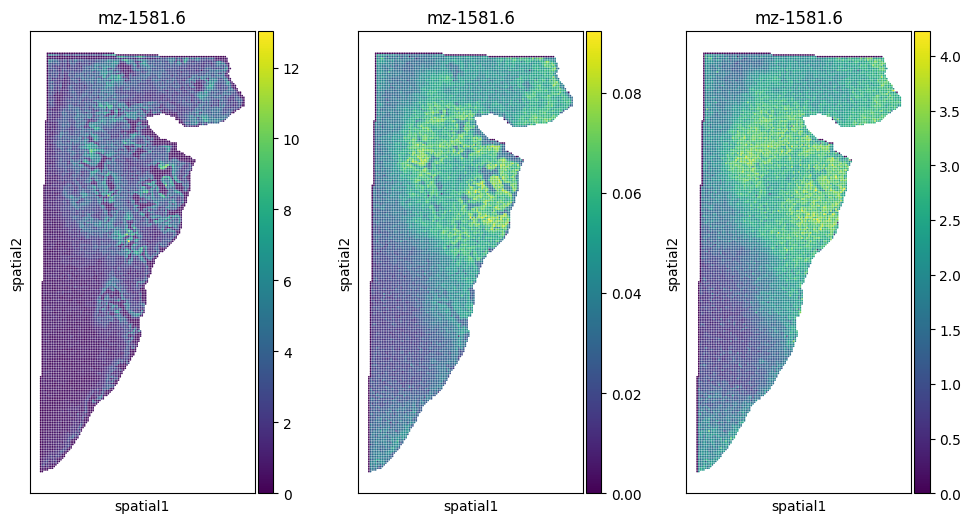

In [ ]:
idx = 27
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

sc.pl.spatial(maldi_sd.tables["maldi_adata"], img_key="hires", 
              color=[maldi_sd["centroids"].columns[idx+4]], size=0.5, spot_size=2,
              alpha_img=0, ax=axs[0], show=False)

sc.pl.spatial(sdata_tic.tables["maldi_adata"], img_key="hires", 
              color=[maldi_sd["centroids"].columns[idx+4]], size=0.5, spot_size=2,
              alpha_img=0, ax=axs[1], show=False)

sc.pl.spatial(sdata_rms.tables["maldi_adata"], img_key="hires", 
              color=[maldi_sd["centroids"].columns[idx+4]], size=0.5, spot_size=2,
              alpha_img=0, ax=axs[2], show=False)